In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import os
import random
from geopy.distance import geodesic
from plotly import express as px
import json


# POPULATION - National (by state)

In [3]:
mexico_states = {
    "Aguascalientes": "01","Baja California": "02", "Baja California Sur": "03","Campeche": "04", "Coahuila de Zaragoza": "05","Colima": "06", "Chiapas": "07","Chihuahua": "08","Ciudad de México": "09","Durango": "10","Guanajuato": "11","Guerrero": "12","Hidalgo": "13","Jalisco": "14","México": "15", "Michoacán de Ocampo": "16", "Morelos": "17", "Nayarit": "18", "Nuevo León": "19", "Oaxaca": "20","Puebla": "21", "Querétaro": "22", "Quintana Roo": "23", "San Luis Potosí": "24", "Sinaloa": "25", "Sonora": "26", "Tabasco": "27", "Tamaulipas": "28", "Tlaxcala": "29", "Veracruz de Ignacio de la Llave": "30", "Yucatán": "31", "Zacatecas": "32"
}
state = 'San Luis Potosí'

filename = f'../Datos Nacionales/POBLACION/ITER_{mexico_states[state]}XLSX20.xlsx'

state_pop_df = pd.read_excel(filename)

#test
print(filename)

state_pop_df['MUN_STR'] = state_pop_df['MUN'].astype(str).str.zfill(3)
state_pop_by_mun = state_pop_df[state_pop_df['NOM_LOC'] == 'Total del Municipio']
state_pop_by_mun.set_index('MUN_STR', inplace=True, drop=False)


../Datos Nacionales/POBLACION/ITER_24XLSX20.xlsx


In [4]:
# JSON downloaded from https://github.com/PhantomInsights/mexico-geojson/blob/main/2023/states/San%20Luis%20Potosí.json
import json
import geopandas as gpd
#Lynda Note: if switched file to "24-SLP.geojson" code doesn't work because no cve_mun key in the file, but if switched to "24-San Luis Potosí.json" code works fine.
# Load GeoJSON file
geojson_path = "../Datos SLP/shapefiles/24-San Luis Potosí.json"
with open(geojson_path) as f:
    slp_geojson = json.load(f)


gdf = gpd.read_file(geojson_path)
gdf = gdf.to_crs(6372)
gdf['centroid'] = gdf.geometry.centroid
gdf['centroid_x'] = gdf['centroid'].x
gdf['centroid_y'] = gdf['centroid'].y

gdf.set_index('CVE_MUN', inplace=True, drop=False)

state_pop_by_mun.loc[:,'X'] = gdf['centroid_x']
state_pop_by_mun.loc[:,'Y'] = gdf['centroid_y']


# Create the choropleth map
fig = px.choropleth(
    state_pop_by_mun,
    geojson=slp_geojson,
    locations='MUN_STR',  # Column in state_pop_df matching GeoJSON feature IDs
    featureidkey="properties.CVE_MUN",  # Key in GeoJSON file for region IDs
    color='POBTOT',  # Column to color by
    title="Population Distribution in SLP",
    color_continuous_scale="greens"
)

# Update map layout
fig.update_geos(fitbounds="locations", visible=False)

# Show the map
# fig.show()

## Converting string latitude or longitude coordinates to floats

In [5]:
import re
def dms_to_decimal(coord):
    coord = coord.strip()
    
    # Regular expression to parse DMS format
    match = re.match(r"(\d+)°(\d+)'([\d.]+)\" ([NSEW])", coord)
    if not match:
        # return 0
        raise ValueError(f"Invalid coordinate format: {coord}")
    
    degrees, minutes, seconds, direction = match.groups()
    degrees = float(degrees)
    minutes = float(minutes)
    seconds = float(seconds)
    
    # Convert to decimal degrees
    decimal = degrees + (minutes / 60) + (seconds / 3600)
    
    # Adjust sign for S/W
    if direction in ['S', 'W']:
        decimal = -decimal
    
    return decimal

print(dms_to_decimal("38°59'43.6\" N"))


38.995444444444445


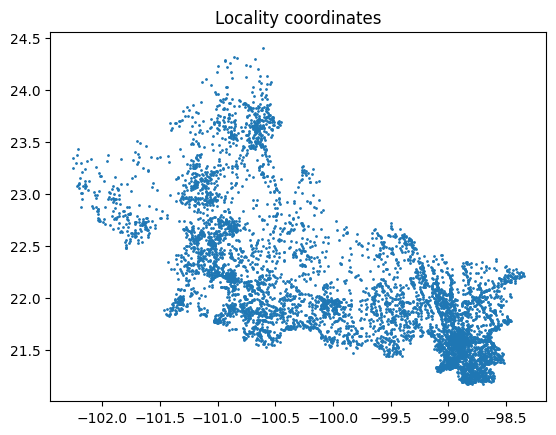

In [6]:
# scatter plot of each of the localities in the population dataframe
ys = [dms_to_decimal(x) for x in state_pop_df['LATITUD'].dropna() ]
xs = [dms_to_decimal(x) for x in state_pop_df['LONGITUD'].dropna()]

plt.scatter(xs,ys, s = 1)
plt.title('Locality coordinates')
plt.show()

In [7]:
def pollutant_effect(pollutant, manzana, pol_name='ALC_mg/L', lon_name = 'LONGITUD', lat_name = 'LATITUD', pop_name = 'POBTOT'):
    try:
        man_loc = (dms_to_decimal(manzana[lat_name]), dms_to_decimal(manzana[lon_name]))
        pop = manzana[pop_name]
        pol_loc = (pollutant[lat_name], pollutant[lon_name])
        distance = geodesic(man_loc, pol_loc).kilometers
        pol_amt = pollutant[pol_name]
        
    except:
        return 0,0,0    
    return pop, distance, pol_amt

water = pd.read_excel("../Datos Nacionales/AGUA/Calidad del Agua Subterranea 2020.xlsx")
water_df_slp = water[water['ESTADO'] == 'SAN LUIS POTOSI']

# TODO: revisit equation Fran and I wrote down to check sum over manzanas or measurements first. ideally, each manzana or locality should have a list of scores
for i, manzana in state_pop_by_mun.iterrows():
    for j, measurement in water_df_slp.iterrows():
        pop, dist, pol_amt = pollutant_effect(measurement, manzana)
        if pop > 0:
           print(pop, dist, pol_amt)


# MORTALITY

## SLP mortality

In [8]:
mortality = pd.read_excel('../Datos SLP/MortalidadCAMA.xlsx', sheet_name='BD')
mortality.head()

,CVEGEO,CVE_ENT,NOM_ENT,CVE_MUN,NOM_MUN,SEXO,CAUSA_D,defunciones,pob10,tasaEspec,eb_bayesR,E_i,smr
0,24001,24,San Luis Potosí,1,Ahualulco del Sonido 13,MUJERES,C50,7.0,5558,125.94,153.3352,15.657842,0.447060
1,24002,24,San Luis Potosí,2,Alaquines,MUJERES,C50,3.0,2410,124.48,176.3339,6.789384,0.441866
2,24003,24,San Luis Potosí,3,Aquismón,MUJERES,C50,10.0,11600,86.21,104.3394,32.679195,0.306005
3,24004,24,San Luis Potosí,4,Armadillo de los Infante,MUJERES,C50,3.0,1400,214.29,245.2087,3.944041,0.760641
4,24005,24,San Luis Potosí,5,Cárdenas,MUJERES,C50,16.0,6172,259.24,262.8585,17.387585,0.920197


CVEGEO                   24028
CVE_ENT                     24
NOM_ENT        San Luis Potosí
CVE_MUN                     28
NOM_MUN        San Luis Potosí
SEXO                   MUJERES
CAUSA_D                    C50
defunciones             1244.0
pob10                   252186
tasaEspec               493.29
eb_bayesR             492.2965
E_i                 710.451334
smr                      1.751
Name: 27, dtype: object


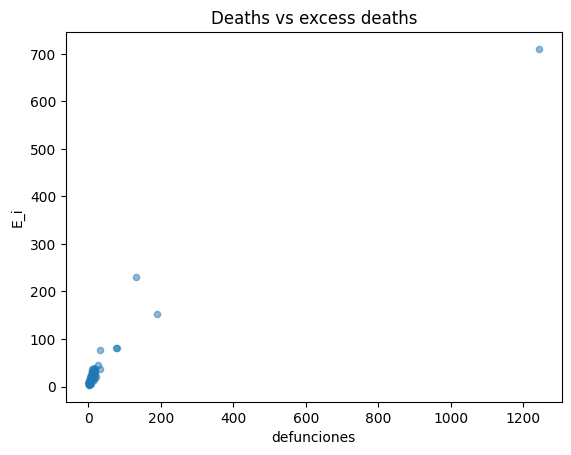

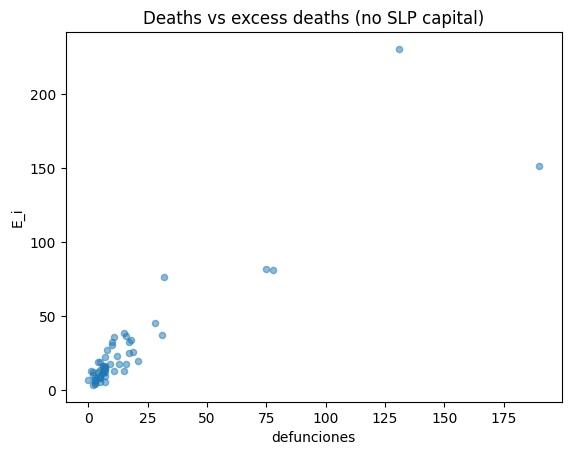

In [9]:
mortality.plot.scatter(x='defunciones', y='E_i', alpha=0.5)
print(mortality.iloc[mortality['tasaEspec'].idxmax()])
plt.title('Deaths vs excess deaths')
plt.show()


mortality_wo_slp = mortality[mortality['NOM_MUN'] != 'San Luis Potosí']
mortality_wo_slp.plot.scatter(x='defunciones', y='E_i', alpha=0.5)
plt.title('Deaths vs excess deaths (no SLP capital)')
plt.show()

In [10]:
np.set_printoptions(precision=4)
np.corrcoef(mortality[['defunciones', 'pob10', 'tasaEspec','eb_bayesR','E_i', 'smr']].values.T)

array([[   nan,    nan,    nan,    nan,    nan,    nan],
       [   nan, 1.    , 0.5262, 0.5431, 1.    , 0.5262],
       [   nan, 0.5262, 1.    , 0.9825, 0.5262, 1.    ],
       [   nan, 0.5431, 0.9825, 1.    , 0.5431, 0.9825],
       [   nan, 1.    , 0.5262, 0.5431, 1.    , 0.5262],
       [   nan, 0.5262, 1.    , 0.9825, 0.5262, 1.    ]])

Some notes on correlation:
* deaths strongly correlated with population (not surprising) and E_i (excess deaths-- also not surprising)
* tasaEspec (age- and sex-adjusted rates) strongly correlated with eb_bayesR (bayesian smoothed rate estimate) -- also not surprising

## National Mortality

In [11]:
# data source: https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=mortalidad_Mortalidad_05_6a897e74-26b8-44de-8994-d9c46acdb64c
nat_mort = pd.read_excel('../Datos Nacionales/MORTALIDAD/Mortalidad_05.xlsx', skiprows=6, index_col="Entidad federativa")

# Grupo quinquenal de edad is all age groups
nat_mort_state_totals = nat_mort[nat_mort['Grupo quinquenal de edad'] == 'Total'].drop('Total')
print(nat_mort_state_totals.head())


                     Grupo quinquenal de edad   2010   2011   2012   2013  \
Entidad federativa                                                          
Aguascalientes                          Total   46.0   59.0   69.0   55.0   
Baja California                         Total  163.0  166.0  180.0  178.0   
Baja California Sur                     Total   31.0   39.0   36.0   34.0   
Campeche                                Total   26.0   22.0   21.0   25.0   
Coahuila de Zaragoza                    Total  158.0  178.0  187.0  195.0   

                       2014   2015   2016   2017   2018   2019   2020   2021  \
Entidad federativa                                                             
Aguascalientes         67.0   71.0   71.0   89.0   99.0   77.0   87.0   76.0   
Baja California       189.0  215.0  192.0  202.0  272.0  268.0  260.0  277.0   
Baja California Sur    31.0   33.0   34.0   55.0   66.0   49.0   57.0   57.0   
Campeche               17.0   29.0   35.0   24.0   37.0   43

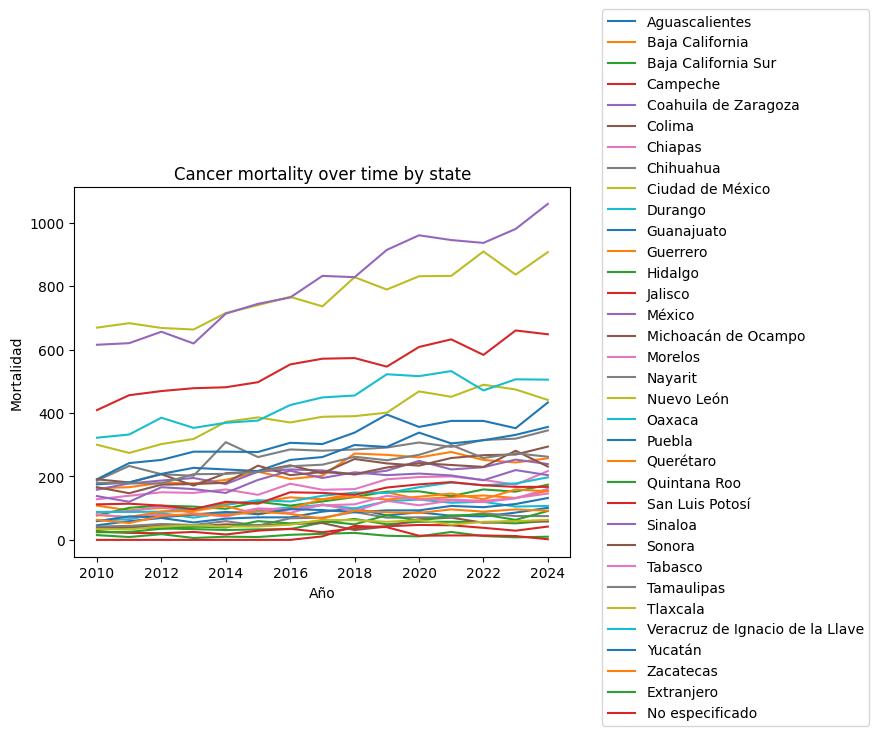

In [12]:
for i, state in nat_mort_state_totals.iterrows():
    years = range(2010, 2025)
    plt.plot(years, [state[str(y)] for y in years], label=i)

plt.title('Cancer mortality over time by state')
plt.legend(loc='upper left', bbox_to_anchor = (1.05, 1.5))
plt.xlabel('Año')
plt.ylabel('Mortalidad')
plt.show()

# WATER

In [13]:
# TODO: sort through the whatsapp to understand what's the difference and source of these datasets
# water = pd.read_excel("../Datos SLP/AmbientalAGUA.xlsx")
water = pd.read_excel("../Datos Nacionales/AGUA/Calidad del Agua Subterranea 2020.xlsx")
# print((water[water['ESTADO'] == 'SAN LUIS POTOSI'][['LATITUD', "LONGITUD"]]))

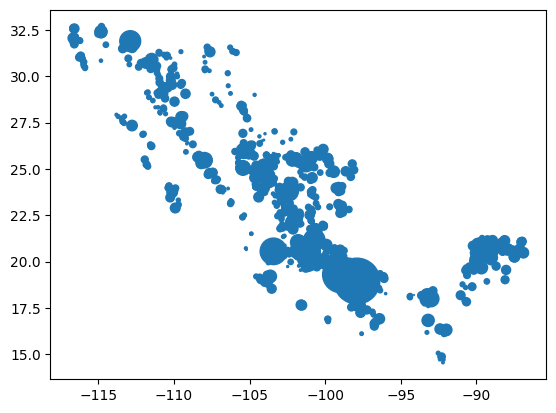

In [14]:
# national visualization of water measurements
x = water['LONGITUD']
y = water['LATITUD']
z = water['ALC_mg/L']
plt.scatter(x,y, s=[np.power(v/50, 2) for v in z])
plt.show()
S = {(xi, yi): zi for xi, yi, zi in zip(x,y,z)}


In [15]:
print(water.groupby(['ESTADO'])[['ALC_mg/L']].describe())
print((water['ALC_mg/L']))



                                ALC_mg/L                                   \
                                   count        mean         std      min   
ESTADO                                                                      
AGUASCALIENTES                      14.0  228.653571   81.110447  116.630   
BAJA CALIFORNIA                     31.0  204.997742   65.499123   65.790   
BAJA CALIFORNIA SUR                 49.0  194.632449   74.088449   66.600   
CAMPECHE                            25.0  261.668400   68.366161  145.160   
CHIAPAS                             21.0  212.443810  130.650882   58.260   
CHIHUAHUA                           35.0  181.045429   67.847897   75.555   
COAHUILA DE ZARAGOZA                59.0  241.445508  107.313486   26.640   
COLIMA                              26.0  220.491346   82.640848   69.930   
DISTRITO FEDERAL                     2.0  204.425000    9.376236  197.795   
DURANGO                            121.0  233.075455   92.652474   62.985   

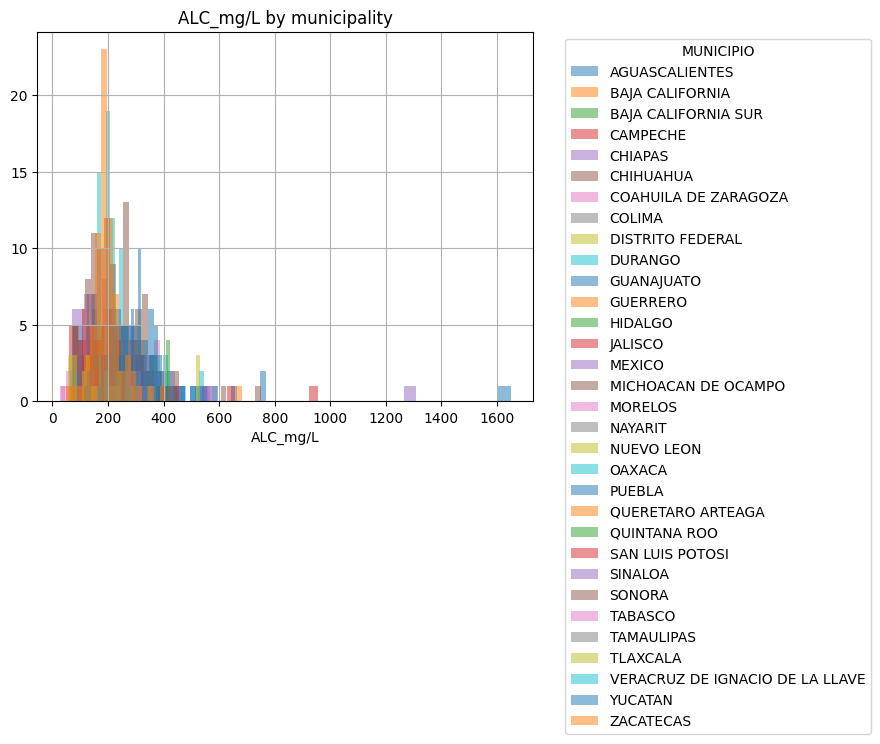

In [16]:
# some visualizations, but for different chemicals.
# to get "rankings" of chemicals from collaborators
chem = 'ALC_mg/L' # 'N_NO3_mg/L'
for municipio, group_data in water.groupby('ESTADO'):
    group_data[chem].hist(bins=30, alpha=0.5, label=municipio)#, color=(random.random(), random.random(), random.random()))
    

plt.legend(title='MUNICIPIO', loc='upper left', bbox_to_anchor=(1.05, 1))
plt.title(f'{chem} by municipality')
plt.xlabel(chem)
plt.show()



In [17]:
print(water.nlargest(50, chem)[['ESTADO', chem, 'CALIDAD_ALC']])
print(water[water['CALIDAD_ALC'] == 'Indeseable como FAAP'].groupby('ESTADO')['ALC_mg/L'].agg(['mean', 'median', 'count']))
# print(len(water[water['CALIDAD_ALC'] == 'Indeseable como FAAP']))


                    ESTADO  ALC_mg/L           CALIDAD_ALC
418                 PUEBLA  1650.000  Indeseable como FAAP
616                 MEXICO  1308.000  Indeseable como FAAP
758                JALISCO   954.600  Indeseable como FAAP
293             GUANAJUATO   768.690  Indeseable como FAAP
303             GUANAJUATO   764.660  Indeseable como FAAP
872                 SONORA   752.000  Indeseable como FAAP
587              ZACATECAS   681.090  Indeseable como FAAP
291             GUANAJUATO   650.000  Indeseable como FAAP
763                JALISCO   646.020  Indeseable como FAAP
401    MICHOACAN DE OCAMPO   626.000  Indeseable como FAAP
116   COAHUILA DE ZARAGOZA   593.490  Indeseable como FAAP
416                 PUEBLA   590.000  Indeseable como FAAP
502                TABASCO   572.760  Indeseable como FAAP
931                SINALOA   559.440  Indeseable como FAAP
297             GUANAJUATO   552.780  Indeseable como FAAP
262                DURANGO   543.900  Indeseable como FA

                   BAD_ALC_FREQ
GUANAJUATO             0.243902
PUEBLA                 0.173913
QUERETARO ARTEAGA      0.166667
HIDALGO                0.162162
CHIAPAS                0.142857
TLAXCALA               0.125000
MEXICO                 0.083333
TABASCO                0.076923
AGUASCALIENTES         0.071429
NUEVO LEON             0.066667


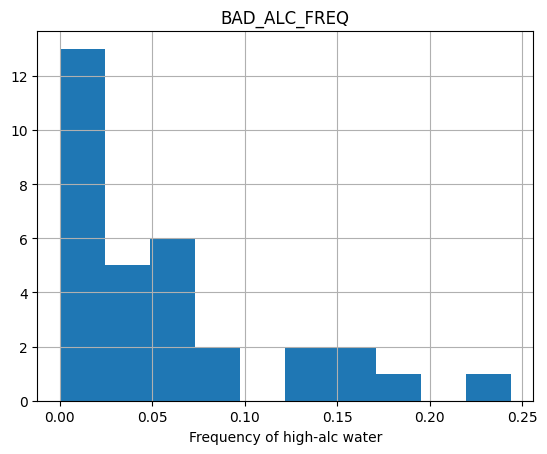

In [18]:
state_summ = pd.DataFrame(index = water['ESTADO'].unique())


bad_freqs = {}

for municipio, group_data in water.groupby('ESTADO'):
    bad_alc_freq = len(group_data[group_data['CALIDAD_ALC'] == 'Indeseable como FAAP']) / len(group_data)
    bad_freqs[municipio] = (bad_alc_freq)
    # print(f'{bad_alc_freq:.2f} of {municipio} measurements rated as bad')

state_summ['BAD_ALC_FREQ'] = bad_freqs
print(state_summ.nlargest(10, 'BAD_ALC_FREQ'))
state_summ.hist('BAD_ALC_FREQ')
plt.xlabel('Frequency of high-alc water')
plt.show()

# Distance- scaled

# Discretization Model

                                            geometry  \
0  POLYGON ((2469886.286 1220244.011, 2474886.286...   
1  POLYGON ((2469886.286 1225244.011, 2474886.286...   
2  POLYGON ((2469886.286 1240244.011, 2474886.286...   
3  POLYGON ((2469886.286 1245244.011, 2474886.286...   
4  POLYGON ((2469886.286 1250244.011, 2474886.286...   

                            center  exposure  
0  POINT (2472386.286 1222744.011)  0.071815  
1  POINT (2472386.286 1227744.011)  0.068333  
2  POINT (2472386.286 1242744.011)  0.061267  
3  POINT (2472386.286 1247744.011)  0.059589  
4  POINT (2472386.286 1252744.011)  0.058114  


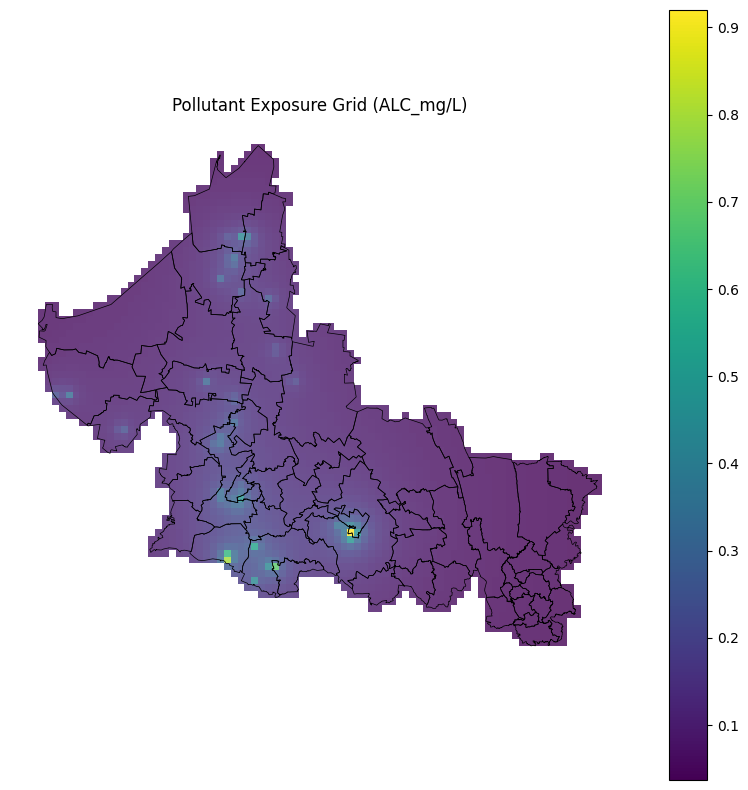

Index(['CLAVE', 'SITIO', 'ORGANISMO_DE_CUENCA', 'ESTADO', 'MUNICIPIO',
       'ACUIFERO', 'SUBTIPO', 'LONGITUD', 'LATITUD', 'PERIODO', 'ALC_mg/L',
       'CALIDAD_ALC', 'CONDUCT_mS/cm', 'CALIDAD_CONDUC', 'SDT_mg/L',
       'SDT_M_mg/L', 'CALIDAD_SDT_ra', 'CALIDAD_SDT_salin', 'FLUORUROS_mg/L',
       'CALIDAD_FLUO', 'DUR_mg/L', 'CALIDAD_DUR', 'COLI_FEC_NMP/100_mL',
       'CALIDAD_COLI_FEC', 'N_NO3_mg/L', 'CALIDAD_N_NO3', 'AS_TOT_mg/L',
       'CALIDAD_AS', 'CD_TOT_mg/L', 'CALIDAD_CD', 'CR_TOT_mg/L', 'CALIDAD_CR',
       'HG_TOT_mg/L', 'CALIDAD_HG', 'PB_TOT_mg/L', 'CALIDAD_PB', 'MN_TOT_mg/L',
       'CALIDAD_MN', 'FE_TOT_mg/L', 'CALIDAD_FE', 'SEMAFORO', 'CONTAMINANTES',
       'CUMPLE_CON_ALC', 'CUMPLE_CON_COND', 'CUMPLE_CON_SDT_ra',
       'CUMPLE_CON_SDT_salin', 'CUMPLE_CON_FLUO', 'CUMPLE_CON_DUR',
       'CUMPLE_CON_CF', 'CUMPLE_CON_NO3', 'CUMPLE_CON_AS', 'CUMPLE_CON_CD',
       'CUMPLE_CON_CR', 'CUMPLE_CON_HG', 'CUMPLE_CON_PB', 'CUMPLE_CON_MN',
       'CUMPLE_CON_FE'],
      dtype='

In [21]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import statsmodels.api as sm
import matplotlib.pyplot as plt

def create_grid(gdf, resolution=5000):

    #Using union of all polygon as region boundary
    boundary = gdf.union_all()
    minx, miny, maxx, maxy = boundary.bounds

    xs = np.arange(minx, maxx, resolution)
    ys = np.arange(miny, maxy, resolution)

    #creating square polygons for each grid cell and checking intersection with boundary
    cells = []
    for x in xs:
        for y in ys:
            cell = Polygon([
                (x, y), 
                (x + resolution, y), 
                (x + resolution, y + resolution), 
                (x, y + resolution)
            ])
            if cell.intersects(boundary):
                cells.append(cell)
    
    #creating GeoDataFrame for grid cells and calculating centroids
    grid = gpd.GeoDataFrame(geometry=cells, crs=gdf.crs)
    grid["center"] = grid.geometry.centroid
    return grid

grid = create_grid(gdf, resolution=5000) 
grid.head()

#converting pollutants points from lat/lon to same CRS as grid
pollutants = gpd.GeoDataFrame(
    water_df_slp,
    geometry=gpd.points_from_xy(water_df_slp['LONGITUD'], water_df_slp['LATITUD']),
    crs=4326).to_crs(epsg=6372)

#defining a function to calculate pollutant exposure for each grid cell
def exposure_score(center_point, pollutants, pol_col = "ALC_mg/L", transform="inverse_distance"):
    #distances in meters from center to each pollutant point
    distances = pollutants.geometry.distance(center_point).replace(0, 1e-6)

    if transform == "inverse_distance":
        weights = 1 / distances
    elif transform == "inverse_distance_squared":
        weights = 1 / distances**2
    else:
        raise ValueError("Unsupported transform type")
    
    pol_values = pollutants[pol_col].fillna(0)
    return np.sum(weights * pol_values)

#calculating exposure scores for each grid cell
def compute_grid_exposure(grid, pollutants, pol_col="ALC_mg/L", transform="inverse_distance"): 
    grid["exposure"] = [ 
        exposure_score(center, pollutants, pol_col, transform) 
        for center in grid["center"] 
    ] 
    return grid

#summing up exposure scores for each grid cell
grid = compute_grid_exposure(grid, pollutants, pol_col="ALC_mg/L")
print(grid.head())

#mortality data has to have a CVE_MUN column to merge with grid
gdf = gdf.reset_index(drop=True)

# ensuring CVE_MUN is string and zero-padded to 3 digits for both gdf and mortality data
gdf["CVE_MUN"] = gdf["CVE_MUN"].astype(str).str.zfill(3)
mortality["CVE_MUN"] = mortality["CVE_MUN"].astype(str).str.zfill(3)

# merging gdf with mortality data to get mortality info for each municipality
mortality_gdf = gdf.merge(mortality, on="CVE_MUN")


#spatial join to assign mortality data to grid cells
grid_with_mortality = gpd.sjoin(grid, mortality_gdf, how="left", predicate='intersects')

#fitting Poisson regression to model mortality as a function of exposure
def fit_poisson(grid):
    pass


# visualizing exposure grid with mortality boundaries
fig, ax = plt.subplots(figsize=(10, 10))

grid.plot(
    column="exposure",
    cmap="viridis",
    legend=True,
    ax=ax,
    alpha=0.8
)

gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Pollutant Exposure Grid (ALC_mg/L)")
ax.set_axis_off()
plt.show()

print(water_df_slp.columns)
print(water_df_slp.head())


                                            geometry  \
0  POLYGON ((2469886.286 1220244.011, 2474886.286...   
1  POLYGON ((2469886.286 1225244.011, 2474886.286...   
2  POLYGON ((2469886.286 1240244.011, 2474886.286...   
3  POLYGON ((2469886.286 1245244.011, 2474886.286...   
4  POLYGON ((2469886.286 1250244.011, 2474886.286...   

                            center  exposure  
0  POINT (2472386.286 1222744.011)  0.241186  
1  POINT (2472386.286 1227744.011)  0.231059  
2  POINT (2472386.286 1242744.011)  0.208693  
3  POINT (2472386.286 1247744.011)  0.202930  
4  POINT (2472386.286 1252744.011)  0.197720  


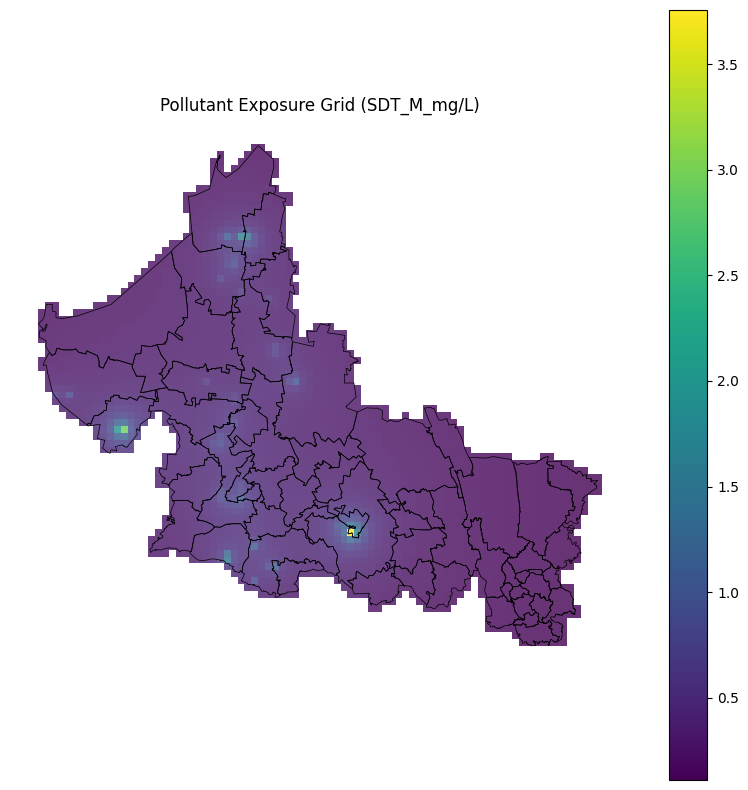

In [30]:
grid2 = create_grid(gdf, resolution=5000) 
grid2.head()


#defining a function to calculate pollutant exposure for each grid cell
def exposure_score(center_point, pollutants, pol_col = "SDT_M_mg/L", transform="inverse_distance"):
    #distances in meters from center to each pollutant point
    distances = pollutants.geometry.distance(center_point).replace(0, 1e-6)

    if transform == "inverse_distance":
        weights = 1 / distances
    elif transform == "inverse_distance_squared":
        weights = 1 / distances**2
    else:
        raise ValueError("Unsupported transform type")
    
    pol_values = pollutants[pol_col].fillna(0)
    return np.sum(weights * pol_values)

#calculating exposure scores for each grid cell
def compute_grid_exposure(grid, pollutants, pol_col="SDT_M_mg/L", transform="inverse_distance"): 
    grid["exposure"] = [ 
        exposure_score(center, pollutants, pol_col, transform) 
        for center in grid["center"] 
    ] 
    return grid

#summing up exposure scores for each grid cell
grid = compute_grid_exposure(grid, pollutants, pol_col="SDT_M_mg/L")
print(grid.head())

#mortality data has to have a CVE_MUN column to merge with grid
gdf = gdf.reset_index(drop=True)

# ensuring CVE_MUN is string and zero-padded to 3 digits for both gdf and mortality data
gdf["CVE_MUN"] = gdf["CVE_MUN"].astype(str).str.zfill(3)
mortality["CVE_MUN"] = mortality["CVE_MUN"].astype(str).str.zfill(3)

# merging gdf with mortality data to get mortality info for each municipality
mortality_gdf = gdf.merge(mortality, on="CVE_MUN")


#spatial join to assign mortality data to grid cells
grid_with_mortality = gpd.sjoin(grid, mortality_gdf, how="left", predicate='intersects')

#fitting Poisson regression to model mortality as a function of exposure
def fit_poisson(grid):
    pass


# visualizing exposure grid with mortality boundaries
fig, ax = plt.subplots(figsize=(10, 10))

grid.plot(
    column="exposure",
    cmap="viridis",
    legend=True,
    ax=ax,
    alpha=0.8
)

gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Pollutant Exposure Grid (SDT_M_mg/L)")
ax.set_axis_off()
plt.show()


                                            geometry  \
0  POLYGON ((2469886.286 1220244.011, 2474886.286...   
1  POLYGON ((2469886.286 1225244.011, 2474886.286...   
2  POLYGON ((2469886.286 1240244.011, 2474886.286...   
3  POLYGON ((2469886.286 1245244.011, 2474886.286...   
4  POLYGON ((2469886.286 1250244.011, 2474886.286...   

                            center  exposure  
0  POINT (2472386.286 1222744.011)  0.000506  
1  POINT (2472386.286 1227744.011)  0.000474  
2  POINT (2472386.286 1242744.011)  0.000412  
3  POINT (2472386.286 1247744.011)  0.000397  
4  POINT (2472386.286 1252744.011)  0.000384  


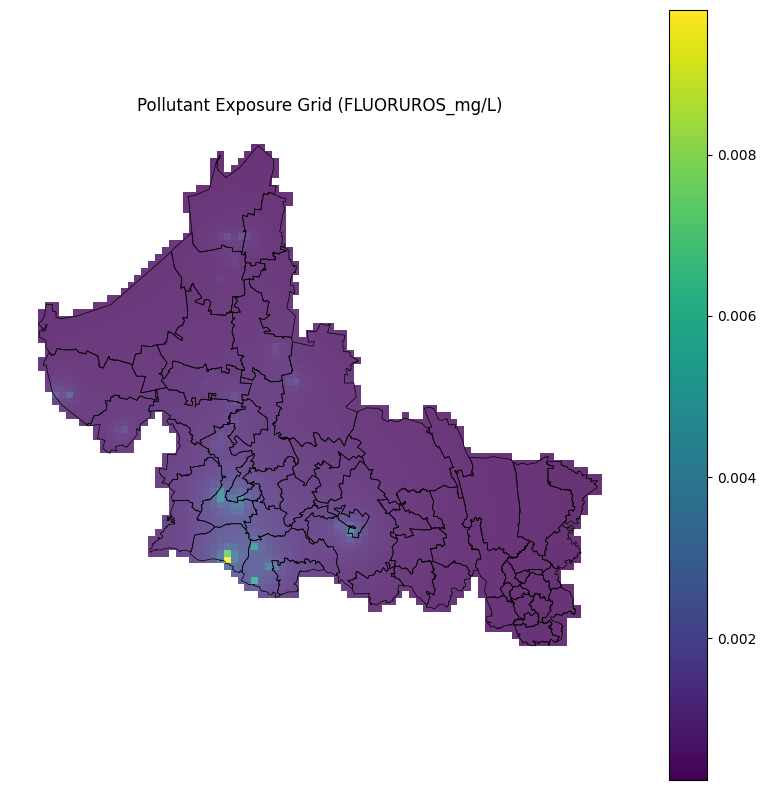

In [33]:
grid3 = create_grid(gdf, resolution=5000) 
grid3.head()


#defining a function to calculate pollutant exposure for each grid cell
def exposure_score(center_point, pollutants, pol_col = "FLUORUROS_mg/L", transform="inverse_distance"):
    #distances in meters from center to each pollutant point
    distances = pollutants.geometry.distance(center_point).replace(0, 1e-6)

    if transform == "inverse_distance":
        weights = 1 / distances
    elif transform == "inverse_distance_squared":
        weights = 1 / distances**2
    else:
        raise ValueError("Unsupported transform type")
    
    # converting pollutant values to numeric, coercing errors to NaN and filling with 0
    pol_values = pd.to_numeric(pollutants[pol_col], errors='coerce').fillna(0)
    return np.sum(weights * pol_values)

#calculating exposure scores for each grid cell
def compute_grid_exposure(grid, pollutants, pol_col="FLUORUROS_mg/L", transform="inverse_distance"): 
    grid["exposure"] = [ 
        exposure_score(center, pollutants, pol_col, transform) 
        for center in grid["center"] 
    ] 
    return grid

#summing up exposure scores for each grid cell
grid = compute_grid_exposure(grid, pollutants, pol_col="FLUORUROS_mg/L")
print(grid.head())

#mortality data has to have a CVE_MUN column to merge with grid
gdf = gdf.reset_index(drop=True)

# ensuring CVE_MUN is string and zero-padded to 3 digits for both gdf and mortality data
gdf["CVE_MUN"] = gdf["CVE_MUN"].astype(str).str.zfill(3)
mortality["CVE_MUN"] = mortality["CVE_MUN"].astype(str).str.zfill(3)

# merging gdf with mortality data to get mortality info for each municipality
mortality_gdf = gdf.merge(mortality, on="CVE_MUN")


#spatial join to assign mortality data to grid cells
grid_with_mortality = gpd.sjoin(grid, mortality_gdf, how="left", predicate='intersects')

#fitting Poisson regression to model mortality as a function of exposure
def fit_poisson(grid):
    pass


# visualizing exposure grid with mortality boundaries
fig, ax = plt.subplots(figsize=(10, 10))

grid.plot(
    column="exposure",
    cmap="viridis",
    legend=True,
    ax=ax,
    alpha=0.8
)

gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Pollutant Exposure Grid (FLUORUROS_mg/L)")
ax.set_axis_off()
plt.show()

                                            geometry  \
0  POLYGON ((2469886.286 1220244.011, 2474886.286...   
1  POLYGON ((2469886.286 1225244.011, 2474886.286...   
2  POLYGON ((2469886.286 1240244.011, 2474886.286...   
3  POLYGON ((2469886.286 1245244.011, 2474886.286...   
4  POLYGON ((2469886.286 1250244.011, 2474886.286...   

                            center  exposure  
0  POINT (2472386.286 1222744.011)  0.093024  
1  POINT (2472386.286 1227744.011)  0.089918  
2  POINT (2472386.286 1242744.011)  0.083424  
3  POINT (2472386.286 1247744.011)  0.081803  
4  POINT (2472386.286 1252744.011)  0.080344  


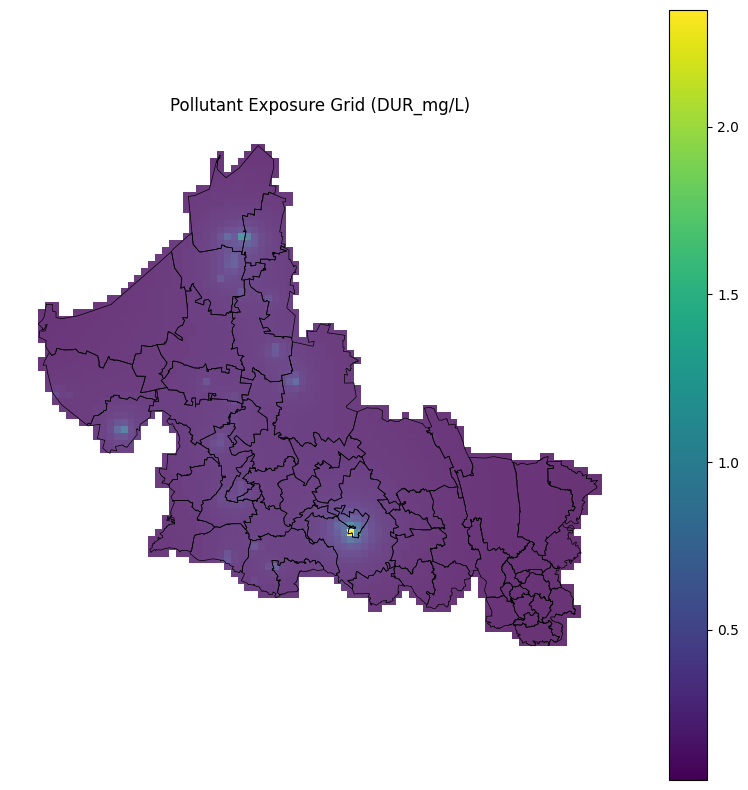

In [34]:
grid4 = create_grid(gdf, resolution=5000) 
grid4.head()


#defining a function to calculate pollutant exposure for each grid cell
def exposure_score(center_point, pollutants, pol_col = "DUR_mg/L", transform="inverse_distance"):
    #distances in meters from center to each pollutant point
    distances = pollutants.geometry.distance(center_point).replace(0, 1e-6)

    if transform == "inverse_distance":
        weights = 1 / distances
    elif transform == "inverse_distance_squared":
        weights = 1 / distances**2
    else:
        raise ValueError("Unsupported transform type")
    
    pol_values = pollutants[pol_col].fillna(0)
    return np.sum(weights * pol_values)

#calculating exposure scores for each grid cell
def compute_grid_exposure(grid, pollutants, pol_col="DUR_mg/L", transform="inverse_distance"): 
    grid["exposure"] = [ 
        exposure_score(center, pollutants, pol_col, transform) 
        for center in grid["center"] 
    ] 
    return grid

#summing up exposure scores for each grid cell
grid = compute_grid_exposure(grid, pollutants, pol_col="DUR_mg/L")
print(grid.head())

#mortality data has to have a CVE_MUN column to merge with grid
gdf = gdf.reset_index(drop=True)

# ensuring CVE_MUN is string and zero-padded to 3 digits for both gdf and mortality data
gdf["CVE_MUN"] = gdf["CVE_MUN"].astype(str).str.zfill(3)
mortality["CVE_MUN"] = mortality["CVE_MUN"].astype(str).str.zfill(3)

# merging gdf with mortality data to get mortality info for each municipality
mortality_gdf = gdf.merge(mortality, on="CVE_MUN")


#spatial join to assign mortality data to grid cells
grid_with_mortality = gpd.sjoin(grid, mortality_gdf, how="left", predicate='intersects')

#fitting Poisson regression to model mortality as a function of exposure
def fit_poisson(grid):
    pass


# visualizing exposure grid with mortality boundaries
fig, ax = plt.subplots(figsize=(10, 10))

grid.plot(
    column="exposure",
    cmap="viridis",
    legend=True,
    ax=ax,
    alpha=0.8
)

gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Pollutant Exposure Grid (DUR_mg/L)")
ax.set_axis_off()
plt.show()

                                            geometry  \
0  POLYGON ((2469886.286 1220244.011, 2474886.286...   
1  POLYGON ((2469886.286 1225244.011, 2474886.286...   
2  POLYGON ((2469886.286 1240244.011, 2474886.286...   
3  POLYGON ((2469886.286 1245244.011, 2474886.286...   
4  POLYGON ((2469886.286 1250244.011, 2474886.286...   

                            center  exposure  
0  POINT (2472386.286 1222744.011)  0.001081  
1  POINT (2472386.286 1227744.011)  0.001004  
2  POINT (2472386.286 1242744.011)  0.000854  
3  POINT (2472386.286 1247744.011)  0.000820  
4  POINT (2472386.286 1252744.011)  0.000790  


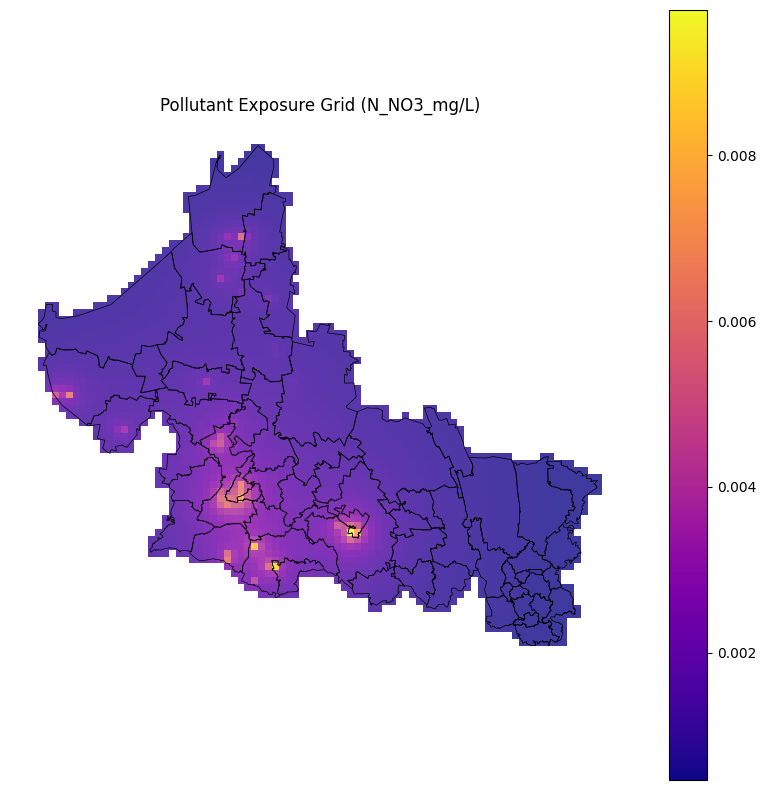

In [36]:
grid5 = create_grid(gdf, resolution=5000) 
grid5.head()


#defining a function to calculate pollutant exposure for each grid cell
def exposure_score(center_point, pollutants, pol_col = "N_NO3_mg/L", transform="inverse_distance"):
    #distances in meters from center to each pollutant point
    distances = pollutants.geometry.distance(center_point).replace(0, 1e-6)

    if transform == "inverse_distance":
        weights = 1 / distances
    elif transform == "inverse_distance_squared":
        weights = 1 / distances**2
    else:
        raise ValueError("Unsupported transform type")
    
    pol_values = pollutants[pol_col].fillna(0)
    return np.sum(weights * pol_values)

#calculating exposure scores for each grid cell
def compute_grid_exposure(grid, pollutants, pol_col="N_NO3_mg/L", transform="inverse_distance"): 
    grid["exposure"] = [ 
        exposure_score(center, pollutants, pol_col, transform) 
        for center in grid["center"] 
    ] 
    return grid

#summing up exposure scores for each grid cell
grid = compute_grid_exposure(grid, pollutants, pol_col="N_NO3_mg/L")
print(grid.head())

#mortality data has to have a CVE_MUN column to merge with grid
gdf = gdf.reset_index(drop=True)

# ensuring CVE_MUN is string and zero-padded to 3 digits for both gdf and mortality data
gdf["CVE_MUN"] = gdf["CVE_MUN"].astype(str).str.zfill(3)
mortality["CVE_MUN"] = mortality["CVE_MUN"].astype(str).str.zfill(3)

# merging gdf with mortality data to get mortality info for each municipality
mortality_gdf = gdf.merge(mortality, on="CVE_MUN")


#spatial join to assign mortality data to grid cells
grid_with_mortality = gpd.sjoin(grid, mortality_gdf, how="left", predicate='intersects')

#fitting Poisson regression to model mortality as a function of exposure
def fit_poisson(grid):
    pass


# visualizing exposure grid with mortality boundaries
fig, ax = plt.subplots(figsize=(10, 10))

grid.plot(
    column="exposure",
    cmap="plasma",
    legend=True,
    ax=ax,
    alpha=0.8
)

gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Pollutant Exposure Grid (N_NO3_mg/L)")
ax.set_axis_off()
plt.show()

In [ ]:
grid6 = create_grid(gdf, resolution=5000) 
grid6.head()


#defining a function to calculate pollutant exposure for each grid cell
def exposure_score(center_point, pollutants, pol_col = "AS_TOT_mg/L", transform="inverse_distance"):
    #distances in meters from center to each pollutant point
    distances = pollutants.geometry.distance(center_point).replace(0, 1e-6)

    if transform == "inverse_distance":
        weights = 1 / distances
    elif transform == "inverse_distance_squared":
        weights = 1 / distances**2
    else:
        raise ValueError("Unsupported transform type")
    
    # converting pollutant values to numeric, coercing errors to NaN and filling with 0
    pol_values = pd.to_numeric(pollutants[pol_col], errors='coerce').fillna(0)
    return np.sum(weights * pol_values)

#calculating exposure scores for each grid cell
def compute_grid_exposure(grid, pollutants, pol_col="AS_TOT_mg/L", transform="inverse_distance"): 
    grid["exposure"] = [ 
        exposure_score(center, pollutants, pol_col, transform) 
        for center in grid["center"] 
    ] 
    return grid

#summing up exposure scores for each grid cell
grid = compute_grid_exposure(grid, pollutants, pol_col="AS_TOT_mg/L")
print(grid.head())

#mortality data has to have a CVE_MUN column to merge with grid
gdf = gdf.reset_index(drop=True)

# ensuring CVE_MUN is string and zero-padded to 3 digits for both gdf and mortality data
gdf["CVE_MUN"] = gdf["CVE_MUN"].astype(str).str.zfill(3)
mortality["CVE_MUN"] = mortality["CVE_MUN"].astype(str).str.zfill(3)

# merging gdf with mortality data to get mortality info for each municipality
mortality_gdf = gdf.merge(mortality, on="CVE_MUN")


#spatial join to assign mortality data to grid cells
grid_with_mortality = gpd.sjoin(grid, mortality_gdf, how="left", predicate='intersects')

#fitting Poisson regression to model mortality as a function of exposure
def fit_poisson(grid):
    pass


# visualizing exposure grid with mortality boundaries
fig, ax = plt.subplots(figsize=(10, 10))

grid.plot(
    column="exposure",
    cmap="plasma",
    legend=True,
    ax=ax,
    alpha=0.8
)

gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_title("Pollutant Exposure Grid (AS_TOT_mg/L)")
ax.set_axis_off()
plt.show()

TypeError: can't multiply sequence by non-int of type 'float'